In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb

import matplotlib.pyplot as plt

In [2]:
Metrico="School_enrollment_secondary"

In [3]:

# Load the Excel file from the "Data-Base" folder
Adolescents_out_school = pd.read_excel(f"Data-Base/{Metrico}.xls")

In [4]:
Adolescents_out_school.shape

(266, 69)

In [5]:
# Define the year columns
year_cols = [str(y) for y in range(1960, 2025)]

# Drop rows where ALL year columns are NaN
Adolescents_out_school = Adolescents_out_school.dropna(
    subset=year_cols,
    how="all"
)


In [6]:
Adolescents_out_school.shape

(234, 69)

In [7]:
Adolescents_out_school.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Aruba,ABW,"School enrollment, secondary (% net)",SE.SEC.NENR,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,AFG,"School enrollment, secondary (% net)",SE.SEC.NENR,NaN,NaN,NaN,NaN,NaN,NaN,...,45.43273,46.65850,48.44288,50.14070,NaN,NaN,NaN,NaN,NaN,NaN
4,Angola,AGO,"School enrollment, secondary (% net)",SE.SEC.NENR,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Albania,ALB,"School enrollment, secondary (% net)",SE.SEC.NENR,NaN,NaN,NaN,NaN,NaN,NaN,...,87.38842,86.48091,86.67260,86.60827,NaN,NaN,NaN,NaN,NaN,NaN
7,Arab World,ARB,"School enrollment, secondary (% net)",SE.SEC.NENR,NaN,NaN,NaN,NaN,NaN,NaN,...,62.06563,62.55911,63.06303,63.51428,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
# missing_mask = Adolescents_out_school["2022"].isna()
# missing_countries = Adolescents_out_school.loc[missing_mask, "Country Name"]
# print("Countries with missing 2022 values:", missing_countries.tolist())

# Randome forest

In [9]:
# # Extract years as features
# years = [str(y) for y in range(1960, 2023)]
# X = Adolescents_out_school[years]

# # Separate features and target (2022)
# X_train = X.drop(columns=["2022"])
# y_train = X["2022"]

# # Mask rows with missing 2022
# mask_missing = y_train.isna()

# # Train model only on rows with known 2022
# rf = RandomForestRegressor(n_estimators=200, random_state=42)
# rf.fit(X_train[~mask_missing], y_train[~mask_missing])

# # Predict missing 2022 values
# y_pred = rf.predict(X_train[mask_missing])

# # Estimate confidence: standard deviation across trees
# all_tree_preds = np.stack([t.predict(X_train[mask_missing]) for t in rf.estimators_], axis=1)
# std_dev = all_tree_preds.std(axis=1)

# # Store predictions
# Adolescents_out_school.loc[mask_missing, "2022_predicted"] = y_pred
# Adolescents_out_school.loc[mask_missing, "2022_confidence"] = 1 / (1 + std_dev)  # Higher = more confident

# print(Adolescents_out_school.loc[mask_missing, ["Country Name", "2022_predicted", "2022_confidence"]])


In [10]:
# ---- Define/collect year columns that actually exist ----
year_cols = sorted([c for c in Adolescents_out_school.columns if str(c).isdigit()])
if "2022" not in year_cols:
    raise ValueError("Column '2022' not found in the DataFrame.")

# Coerce year columns to numeric
Adolescents_out_school[year_cols] = Adolescents_out_school[year_cols].apply(
    pd.to_numeric, errors="coerce"
)

# Prepare features/target
feature_years = [y for y in year_cols if y != "2022"]
X_all = Adolescents_out_school[feature_years]
y_all = Adolescents_out_school["2022"]
mask_missing = y_all.isna()

# Ensure output columns exist
if "2022_predicted" not in Adolescents_out_school.columns:
    Adolescents_out_school["2022_predicted"] = np.nan
if "2022_confidence" not in Adolescents_out_school.columns:
    Adolescents_out_school["2022_confidence"] = np.nan

n_train = (~mask_missing).sum()
n_miss  = mask_missing.sum()

if n_miss == 0:
    # Nothing to predict
    Adolescents_out_school.loc[~mask_missing, "2022_confidence"] = 1.0
else:
    if n_train > 0:
        # Train RF on known 2022 rows
        rf = RandomForestRegressor(n_estimators=200, random_state=42)
        rf.fit(X_all[~mask_missing], y_all[~mask_missing])

        # Predict missing 2022
        y_pred = rf.predict(X_all[mask_missing])

        # Std across trees as uncertainty proxy
        all_tree_preds = np.stack(
            [t.predict(X_all[mask_missing]) for t in rf.estimators_], axis=1
        )
        std_dev = all_tree_preds.std(axis=1)
        rel_conf = 1.0 / (1.0 + std_dev)

        Adolescents_out_school.loc[mask_missing, "2022_predicted"]  = y_pred
        Adolescents_out_school.loc[mask_missing, "2022_confidence"] = rel_conf
        Adolescents_out_school.loc[~mask_missing, "2022_confidence"] = 1.0
    else:
        # Fallback: no known 2022 anywhere -> interpolate per row
        def impute_row(row):
            # Prefer midpoint of 2021 & 2023 if both exist
            v21 = row.get("2021", np.nan)
            v23 = row.get("2023", np.nan)
            if pd.notna(v21) and pd.notna(v23):
                return pd.Series({"2022_predicted": (v21 + v23) / 2.0, "2022_confidence": 0.8})
            elif pd.notna(v21):
                return pd.Series({"2022_predicted": v21, "2022_confidence": 0.6})
            elif pd.notna(v23):
                return pd.Series({"2022_predicted": v23, "2022_confidence": 0.6})
            else:
                # Linear interpolate across all year columns
                s = row[year_cols].astype(float)
                s_interp = s.interpolate(limit_direction="both")
                return pd.Series({"2022_predicted": s_interp.get("2022", np.nan), "2022_confidence": 0.5})

        fill = Adolescents_out_school.loc[mask_missing].apply(impute_row, axis=1)
        Adolescents_out_school.loc[mask_missing, "2022_predicted"]  = fill["2022_predicted"].values
        Adolescents_out_school.loc[mask_missing, "2022_confidence"] = fill["2022_confidence"].values
        # For rows that already had 2022 values (none in this branch) we'd set 1.0; keep as-is here.

# Inspect results for the imputed rows
cols_show = ["Country Name", "Country Code", "2022", "2022_predicted", "2022_confidence"]
print(Adolescents_out_school.loc[mask_missing, cols_show].head(12))


            Country Name Country Code  2022  2022_predicted  2022_confidence
0                  Aruba          ABW   NaN        76.94634              0.5
2            Afghanistan          AFG   NaN        50.14070              0.5
4                 Angola          AGO   NaN        11.29064              0.5
5                Albania          ALB   NaN        86.60827              0.5
7             Arab World          ARB   NaN        63.51428              0.5
8   United Arab Emirates          ARE   NaN        92.79992              0.5
9              Argentina          ARG   NaN        90.79605              0.5
10               Armenia          ARM   NaN        87.74122              0.5
12   Antigua and Barbuda          ATG   NaN        88.78981              0.5
13             Australia          AUS   NaN        92.28431              0.5
14               Austria          AUT   NaN        87.00131              0.5
15            Azerbaijan          AZE   NaN        88.53256              0.5

In [11]:
Adolescents_out_school.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2022_predicted,2022_confidence
0,Aruba,ABW,"School enrollment, secondary (% net)",SE.SEC.NENR,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,76.94634,0.5
2,Afghanistan,AFG,"School enrollment, secondary (% net)",SE.SEC.NENR,NaN,NaN,NaN,NaN,NaN,NaN,...,48.44288,50.14070,NaN,NaN,NaN,NaN,NaN,NaN,50.14070,0.5
4,Angola,AGO,"School enrollment, secondary (% net)",SE.SEC.NENR,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.29064,0.5
5,Albania,ALB,"School enrollment, secondary (% net)",SE.SEC.NENR,NaN,NaN,NaN,NaN,NaN,NaN,...,86.67260,86.60827,NaN,NaN,NaN,NaN,NaN,NaN,86.60827,0.5
7,Arab World,ARB,"School enrollment, secondary (% net)",SE.SEC.NENR,NaN,NaN,NaN,NaN,NaN,NaN,...,63.06303,63.51428,NaN,NaN,NaN,NaN,NaN,NaN,63.51428,0.5


In [12]:
missing_mask = Adolescents_out_school["2022"].isna()
missing_countries = Adolescents_out_school.loc[missing_mask, "Country Name"]
print("Countries with missing 2022 values:", missing_countries.tolist())

Countries with missing 2022 values: ['Aruba', 'Afghanistan', 'Angola', 'Albania', 'Arab World', 'United Arab Emirates', 'Argentina', 'Armenia', 'Antigua and Barbuda', 'Australia', 'Austria', 'Azerbaijan', 'Burundi', 'Belgium', 'Benin', 'Burkina Faso', 'Bangladesh', 'Bulgaria', 'Bahrain', 'Bahamas, The', 'Belarus', 'Belize', 'Bermuda', 'Bolivia', 'Brazil', 'Barbados', 'Brunei Darussalam', 'Bhutan', 'Botswana', 'Central African Republic', 'Canada', 'Central Europe and the Baltics', 'Switzerland', 'Chile', "Cote d'Ivoire", 'Cameroon', 'Congo, Dem. Rep.', 'Congo, Rep.', 'Colombia', 'Comoros', 'Cabo Verde', 'Costa Rica', 'Caribbean small states', 'Cuba', 'Cyprus', 'Czechia', 'Germany', 'Djibouti', 'Dominica', 'Denmark', 'Dominican Republic', 'Algeria', 'East Asia & Pacific (excluding high income)', 'Early-demographic dividend', 'East Asia & Pacific', 'Europe & Central Asia (excluding high income)', 'Europe & Central Asia', 'Ecuador', 'Egypt, Arab Rep.', 'Euro area', 'Eritrea', 'Spain', 'Est

In [13]:
# Select only required columns
new_Adolescents_out_school = Adolescents_out_school[[
    "Country Name", 
    "Country Code", 
    "2022", 
    "2022_predicted", 
    "2022_confidence"
]]

In [14]:
new_Adolescents_out_school.head(50)

,Country Name,Country Code,2022,2022_predicted,2022_confidence
0,Aruba,ABW,NaN,76.94634,0.5
2,Afghanistan,AFG,NaN,50.14070,0.5
4,Angola,AGO,NaN,11.29064,0.5
5,Albania,ALB,NaN,86.60827,0.5
7,Arab World,ARB,NaN,63.51428,0.5
8,United Arab Emirates,ARE,NaN,92.79992,0.5
9,Argentina,ARG,NaN,90.79605,0.5
10,Armenia,ARM,NaN,87.74122,0.5
12,Antigua and Barbuda,ATG,NaN,88.78981,0.5
13,Australia,AUS,NaN,92.28431,0.5


In [15]:
# Keep only rows where 2022 column is NOT missing
non_missing_2022 = new_Adolescents_out_school[new_Adolescents_out_school["2022"].notna()]

In [16]:
non_missing_2022.head()

,Country Name,Country Code,2022,2022_predicted,2022_confidence


In [17]:

# Case 1: If 2022 is NaN → replace it with 2022_predicted (keep confidence as-is)
mask_2022_missing = new_Adolescents_out_school["2022"].isna()
new_Adolescents_out_school.loc[mask_2022_missing, "2022"] = new_Adolescents_out_school.loc[mask_2022_missing, "2022_predicted"]

# Case 2: If 2022_predicted is NaN → replace it with 2022 and force confidence = 1
mask_pred_missing = new_Adolescents_out_school["2022_predicted"].isna()
new_Adolescents_out_school.loc[mask_pred_missing, "2022_predicted"] = new_Adolescents_out_school.loc[mask_pred_missing, "2022"]
new_Adolescents_out_school.loc[mask_pred_missing, "2022_confidence"] = 1


In [18]:
new_Adolescents_out_school.head(50)

,Country Name,Country Code,2022,2022_predicted,2022_confidence
0,Aruba,ABW,76.94634,76.94634,0.5
2,Afghanistan,AFG,50.14070,50.14070,0.5
4,Angola,AGO,11.29064,11.29064,0.5
5,Albania,ALB,86.60827,86.60827,0.5
7,Arab World,ARB,63.51428,63.51428,0.5
8,United Arab Emirates,ARE,92.79992,92.79992,0.5
9,Argentina,ARG,90.79605,90.79605,0.5
10,Armenia,ARM,87.74122,87.74122,0.5
12,Antigua and Barbuda,ATG,88.78981,88.78981,0.5
13,Australia,AUS,92.28431,92.28431,0.5


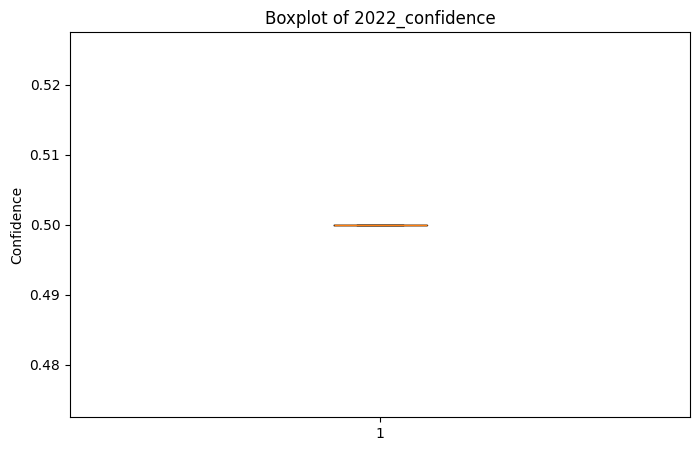

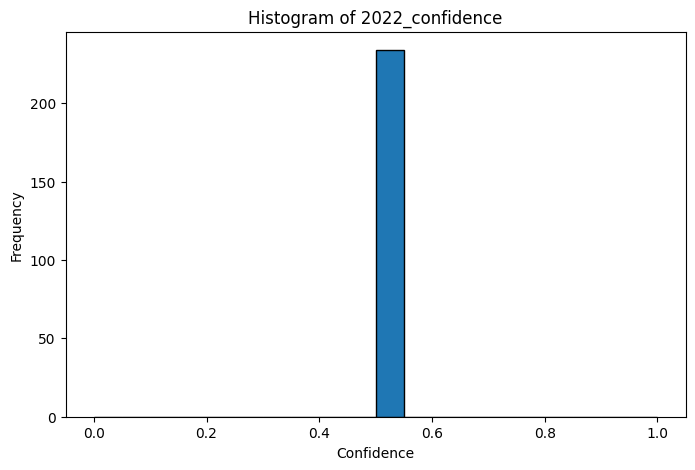

In [19]:
import matplotlib.pyplot as plt

# Assuming new_Adolescents_out_school dataframe is already available in memory

# Create a boxplot for 2022_confidence
plt.figure(figsize=(8,5))
plt.boxplot(new_Adolescents_out_school["2022_confidence"].dropna(), vert=True)
plt.title("Boxplot of 2022_confidence")
plt.ylabel("Confidence")
plt.show()

# Create a histogram for 2022_confidence
plt.figure(figsize=(8,5))
plt.hist(new_Adolescents_out_school["2022_confidence"].dropna(), bins=20, edgecolor='black')
plt.title("Histogram of 2022_confidence")
plt.xlabel("Confidence")
plt.ylabel("Frequency")
plt.show()


# xgboost 

In [20]:
# Load the Excel file from the "Data-Base" folder
Adolescents_out_school = pd.read_excel(f"Data-Base/{Metrico}.xls")

In [21]:
# Define the year columns
year_cols = [str(y) for y in range(1960, 2025)]

# Drop rows where ALL year columns are NaN
Adolescents_out_school = Adolescents_out_school.dropna(
    subset=year_cols,
    how="all"
)

In [22]:
Adolescents_out_school.shape

(234, 69)

In [23]:
Adolescents_out_school.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Aruba,ABW,"School enrollment, secondary (% net)",SE.SEC.NENR,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,AFG,"School enrollment, secondary (% net)",SE.SEC.NENR,NaN,NaN,NaN,NaN,NaN,NaN,...,45.43273,46.65850,48.44288,50.14070,NaN,NaN,NaN,NaN,NaN,NaN
4,Angola,AGO,"School enrollment, secondary (% net)",SE.SEC.NENR,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Albania,ALB,"School enrollment, secondary (% net)",SE.SEC.NENR,NaN,NaN,NaN,NaN,NaN,NaN,...,87.38842,86.48091,86.67260,86.60827,NaN,NaN,NaN,NaN,NaN,NaN
7,Arab World,ARB,"School enrollment, secondary (% net)",SE.SEC.NENR,NaN,NaN,NaN,NaN,NaN,NaN,...,62.06563,62.55911,63.06303,63.51428,NaN,NaN,NaN,NaN,NaN,NaN


In [24]:
# # !pip install xgboost  # uncomment if needed
# import xgboost as xgb

# # ---- CONFIG ----
# B = 50  # number of bootstrap models (increase for smoother confidence)
# RANDOM_STATE = 42
# xgb_params = dict(
#     n_estimators=400,
#     learning_rate=0.05,
#     max_depth=4,
#     subsample=0.9,
#     colsample_bytree=0.9,
#     reg_lambda=1.0,
#     objective="reg:squarederror",
#     random_state=RANDOM_STATE,
# )

# # ---- DATA ----
# # Adolescents_out_school: columns include 'Country Name','Country Code',
# # and year columns '1960'...'2024' as strings.
# years = [str(y) for y in range(1960, 2024)]
# feature_years = [y for y in years if y != "2022"]  # exclude target

# X_all = Adolescents_out_school[feature_years]
# y_all = Adolescents_out_school["2022"]

# mask_missing = y_all.isna()
# idx_train = np.where(~mask_missing)[0]
# idx_miss  = np.where(mask_missing)[0]

# X_train = X_all.iloc[idx_train]
# y_train = y_all.iloc[idx_train]
# X_miss  = X_all.iloc[idx_miss]

# # ---- BOOTSTRAP + XGBoost ----
# # Train B bootstrap models on known 2022 rows; predict missing rows each time
# rng = np.random.default_rng(RANDOM_STATE)
# preds_matrix = np.zeros((len(idx_miss), B))

# for b in range(B):
#     # bootstrap sample of training indices
#     boot_idx = rng.choice(len(idx_train), size=len(idx_train), replace=True)
#     Xb = X_train.iloc[boot_idx]
#     yb = y_train.iloc[boot_idx]

#     model = xgb.XGBRegressor(**xgb_params)
#     model.fit(Xb, yb)
#     preds_matrix[:, b] = model.predict(X_miss)

# # ---- AGGREGATE PREDICTIONS + CONFIDENCE ----
# y_pred = preds_matrix.mean(axis=1)
# std_dev = preds_matrix.std(axis=1)

# # Relative confidence: higher = more stable across models
# rel_conf = 1.0 / (1.0 + std_dev)

# # ---- WRITE BACK ----
# Adolescents_out_school["2022_predicted"] = np.nan
# Adolescents_out_school["2022_confidence"] = np.nan

# Adolescents_out_school.loc[mask_missing, "2022_predicted"]  = y_pred
# Adolescents_out_school.loc[mask_missing, "2022_confidence"] = rel_conf

# # (Optional) Set confidence=1 for rows with observed 2022
# Adolescents_out_school.loc[~mask_missing, "2022_confidence"] = 1.0

In [25]:
# ---------------- CONFIG ----------------
B = 50  # number of bootstrap models (increase for smoother confidence)
RANDOM_STATE = 42
xgb_params = dict(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    objective="reg:squarederror",
    random_state=RANDOM_STATE,
)

# ---------------- DATA PREP ----------------
# Use whatever numeric year columns actually exist
year_cols = sorted([c for c in Adolescents_out_school.columns if str(c).isdigit()])

if "2022" not in year_cols:
    raise ValueError("Column '2022' not found in Adolescents_out_school.")

# Coerce year columns to numeric
Adolescents_out_school[year_cols] = Adolescents_out_school[year_cols].apply(
    pd.to_numeric, errors="coerce"
)

feature_years = [y for y in year_cols if y != "2022"]  # exclude the target

X_all = Adolescents_out_school[feature_years]
y_all = Adolescents_out_school["2022"]

mask_missing = y_all.isna()
idx_train = np.where(~mask_missing)[0]
idx_miss  = np.where(mask_missing)[0]

# Ensure output columns exist
if "2022_predicted" not in Adolescents_out_school.columns:
    Adolescents_out_school["2022_predicted"] = np.nan
if "2022_confidence" not in Adolescents_out_school.columns:
    Adolescents_out_school["2022_confidence"] = np.nan

n_train = len(idx_train)
n_miss  = len(idx_miss)

# If nothing to predict, just mark confidence for observed rows and stop
if n_miss == 0:
    Adolescents_out_school.loc[~mask_missing, "2022_confidence"] = 1.0
else:
    # If we have at least one known 2022, train XGBoost (bootstrap for confidence)
    if n_train > 0:
        X_train = X_all.iloc[idx_train]
        y_train = y_all.iloc[idx_train]
        X_miss  = X_all.iloc[idx_miss]

        rng = np.random.default_rng(RANDOM_STATE)
        preds_matrix = np.zeros((n_miss, B))

        for b in range(B):
            # bootstrap sample of the training rows (size >= 1 guaranteed because n_train > 0)
            boot_idx = rng.choice(n_train, size=n_train, replace=True)
            Xb = X_train.iloc[boot_idx]
            yb = y_train.iloc[boot_idx]

            model = xgb.XGBRegressor(**xgb_params)
            model.fit(Xb, yb)
            preds_matrix[:, b] = model.predict(X_miss)

        # Aggregate predictions + relative confidence from dispersion
        y_pred = preds_matrix.mean(axis=1)
        std_dev = preds_matrix.std(axis=1)
        rel_conf = 1.0 / (1.0 + std_dev)

        Adolescents_out_school.loc[mask_missing, "2022_predicted"]  = y_pred
        Adolescents_out_school.loc[mask_missing, "2022_confidence"] = rel_conf
        Adolescents_out_school.loc[~mask_missing, "2022_confidence"] = 1.0

    else:
        # -------- Fallback when there are ZERO known 2022 labels globally --------
        # Fill from neighbors if possible, otherwise interpolate across all years
        def fallback_impute(row):
            v21 = row.get("2021", np.nan)
            v23 = row.get("2023", np.nan)
            if pd.notna(v21) and pd.notna(v23):
                return pd.Series({"2022_predicted": (v21 + v23) / 2.0, "2022_confidence": 0.8})
            elif pd.notna(v21):
                return pd.Series({"2022_predicted": v21, "2022_confidence": 0.6})
            elif pd.notna(v23):
                return pd.Series({"2022_predicted": v23, "2022_confidence": 0.6})
            else:
                s = row[year_cols].astype(float)
                s_interp = s.interpolate(limit_direction="both")
                return pd.Series({"2022_predicted": s_interp.get("2022", np.nan), "2022_confidence": 0.5})

        fill = Adolescents_out_school.loc[mask_missing].apply(fallback_impute, axis=1)
        Adolescents_out_school.loc[mask_missing, "2022_predicted"]  = fill["2022_predicted"].values
        Adolescents_out_school.loc[mask_missing, "2022_confidence"] = fill["2022_confidence"].values
        # (Rows with observed 2022 don't exist in this branch, so nothing to set to 1.0)

# (Optional) inspect predicted rows
# print(Adolescents_out_school.loc[mask_missing, ["Country Name","Country Code","2022_predicted","2022_confidence"]]
#       .sort_values("2022_confidence"))


In [26]:
# Select only required columns
new_Adolescents_out_school = Adolescents_out_school[[
    "Country Name", 
    "Country Code", 
    "2022", 
    "2022_predicted", 
    "2022_confidence"
]]

In [27]:
# Case 1: If 2022 is NaN → replace it with 2022_predicted (keep confidence as-is)
mask_2022_missing = new_Adolescents_out_school["2022"].isna()
new_Adolescents_out_school.loc[mask_2022_missing, "2022"] = new_Adolescents_out_school.loc[mask_2022_missing, "2022_predicted"]

# Case 2: If 2022_predicted is NaN → replace it with 2022 and force confidence = 1
mask_pred_missing = new_Adolescents_out_school["2022_predicted"].isna()
new_Adolescents_out_school.loc[mask_pred_missing, "2022_predicted"] = new_Adolescents_out_school.loc[mask_pred_missing, "2022"]
new_Adolescents_out_school.loc[mask_pred_missing, "2022_confidence"] = 1

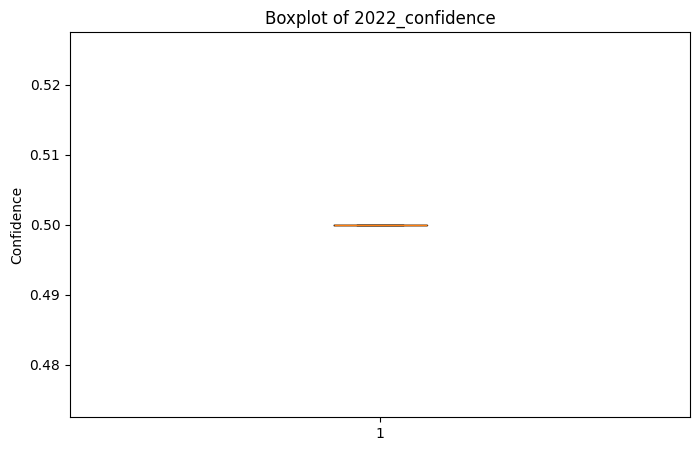

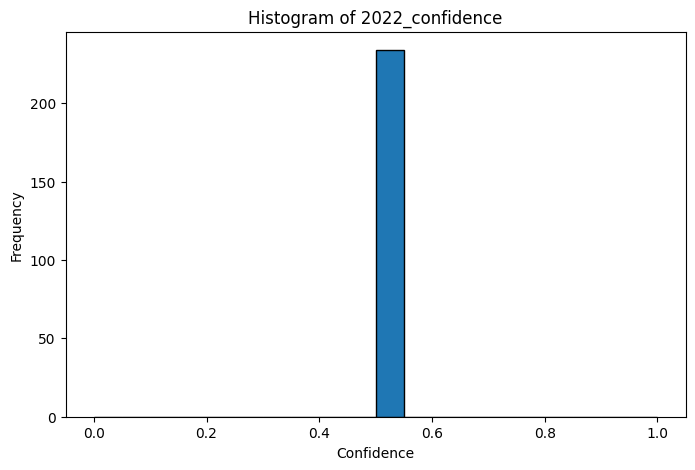

In [28]:
import matplotlib.pyplot as plt

# Assuming new_Adolescents_out_school dataframe is already available in memory

# Create a boxplot for 2022_confidence
plt.figure(figsize=(8,5))
plt.boxplot(new_Adolescents_out_school["2022_confidence"].dropna(), vert=True)
plt.title("Boxplot of 2022_confidence")
plt.ylabel("Confidence")
plt.show()

# Create a histogram for 2022_confidence
plt.figure(figsize=(8,5))
plt.hist(new_Adolescents_out_school["2022_confidence"].dropna(), bins=20, edgecolor='black')
plt.title("Histogram of 2022_confidence")
plt.xlabel("Confidence")
plt.ylabel("Frequency")
plt.show()


In [29]:
new_Adolescents_out_school.head()

,Country Name,Country Code,2022,2022_predicted,2022_confidence
0,Aruba,ABW,76.94634,76.94634,0.5
2,Afghanistan,AFG,50.14070,50.14070,0.5
4,Angola,AGO,11.29064,11.29064,0.5
5,Albania,ALB,86.60827,86.60827,0.5
7,Arab World,ARB,63.51428,63.51428,0.5


In [30]:
new_Adolescents_out_school.shape

(234, 5)

In [31]:
# Keep only rows with confidence >= 0.6
high_confidence = new_Adolescents_out_school[
    new_Adolescents_out_school["2022_confidence"] >= 0.5
]

In [32]:
high_confidence.shape

(234, 5)

In [33]:
mar_row = new_Adolescents_out_school[
    new_Adolescents_out_school["Country Code"] == "MAR"
]

print(mar_row)

    Country Name Country Code     2022  2022_predicted  2022_confidence
148      Morocco          MAR  64.4924         64.4924              0.5


In [34]:
# Save as CSV
high_confidence.to_csv(f"N_{Metrico}.csv", index=False)

# Save as Excel (.xlsx modern format)
high_confidence.to_excel(f"N_{Metrico}.xlsx", index=False)

print(f"✅ Files saved: N_{Metrico}.csv and N_{Metrico}.xlsx")



✅ Files saved: N_School_enrollment_secondary.csv and N_School_enrollment_secondary.xlsx
